# Bath_dMFA_2026 Software 5 - Sample solution

## Energy and GHG of the vehicle fleet in the EUR20 countries
This software workbook completes the calculations with the stock-flow-service nexus of the Euro countries' vehicle fleet. Here, we calculate the product operation/functions (vehicle-km), the final energy required, and the GHG emissions of the different scopes.

### Task 1: How large is the function (in vehicle-km/yr) provided by the vehicle fleet?
Calculate and plot the results!

The total kilometrage provided by the fleet, *KM(t)*, is given by the following equation:

$$ KM(t) = \sum_c km(t) \cdot S(t,c) $$

Below, we first read the data for *km(t)* and then do the calculation with the np.einsum function.

In [1]:
# First, import required libraries:
import pandas as pd   # dataframe library, used for fast import/export from/to excel and for organizing the data.
import numpy as np    # math library
import matplotlib.pyplot as plt  # plotting library
import pickle

In [2]:
with open('Bath_dMFA_2026_Software_3_Results.pkl', 'rb') as f:
    DynFleetResults = pickle.load(f) # deserialize using load()
print(DynFleetResults['I_Veh_cT' ].shape)
print(DynFleetResults['S_Veh_tcT'].shape)
print(DynFleetResults['O_Veh_tcT'].shape)

(71, 2)
(71, 71, 2)
(71, 71, 2)


In [3]:
# Time series of kilometrage (annual, per vehicle)
km_t = pd.read_excel('Bath_dMFA_2026_Software_Data.xlsx', sheet_name='Kilometrage', index_col=0).values.squeeze() # ignore additional dimension of length 1
print(km_t.shape) # 71 years (rows), applies to all age-cohorts and drive technologies

(71,)


In [4]:
KM_t = np.einsum('tcT,t->t',DynFleetResults['S_Veh_tcT'],km_t)

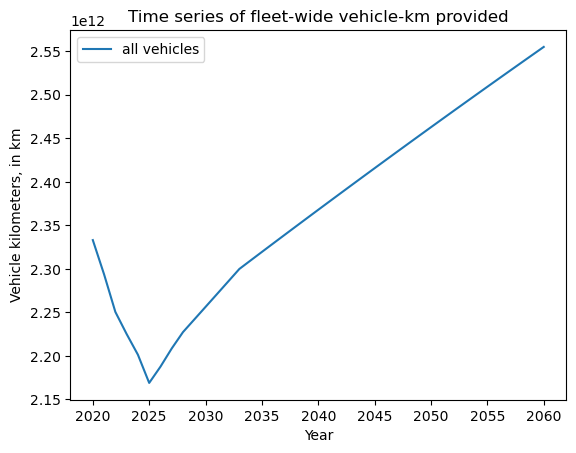

In [5]:
plt.plot(np.arange(2020,2061,1),KM_t[30::]) # plot with given x-axis values, generated with the np.arange command
plt.title('Time series of fleet-wide vehicle-km provided')
plt.ylabel('Vehicle kilometers, in km')
plt.xlabel('Year')
plt.legend(['all vehicles'])
plt.savefig('Fleet_km_t.png', dpi = 300) # save figure with the modifications made above.

For the given scenario, after a slight decline until 2025, the fleet-wide km are increasing over time, mainly due to the increase in passenger-km/yr in the given scenario data.

### Task 1a: In 2040, how many % of the vehicle-km/yr are provided by vehicles that are 10 years old or older?

Calculate and interpret the result!


Here, we calculate the total kilometrage provided by the fleet, *KM(t,c)*, broken down by age-cohort *c*, which is given by the following equation:

$$ KM(t,c) = km(t) \cdot S(t,c) $$

Below, we do the calculation with the np.einsum function.

In [6]:
KM_t_c = np.einsum('tcT,t->tc',DynFleetResults['S_Veh_tcT'],km_t)

Now, we slice the km by year *t* and age-cohort *c* to first get all km in 2040 and then only those by age-cohorts from 2002 up to and including 2030:

In [7]:
km_2040_all = KM_t_c[50,:].sum() # index 30 for 2020, index 50 for 2040
print(km_2040_all)
km_2040_10plus = KM_t_c[50,0:40].sum() # index 0 for 2002, index 28 for 2030, plus one because Python stops at second-to-last element in the list of age-cohorts.
print(km_2040_10plus)
km_share_10plus = 100 * km_2040_10plus / km_2040_all
print(km_share_10plus)

2367905264827.587
740388449266.772
31.267655014090337


According to the given scenario, in the EUR20 countries, in 2040, about 31% of all vehicle-km are delivered by vehicles that were registered in 2030 or before. The other 69% are delivered by vehicles registered between 2031 and 2040.

### Task 2: Calculate future fleet-wide final energy demand by factoring in the kilometrage (by time) and the specific energy demand per km (per age-cohort)

For each year *t*, the time series *km(t)* indicates how many km each car is driven per year on average. This value may change over time, it may increase, for example, if more cars are used for carsharing. 

For each age-cohort, the cars have a specific fuel efficieny *MJ(c)*, which can decline over time, as cars become more fuel efficient due to better engineering, or increase over time, as cars become larger.

The total energy consumption of the fleet, *E(t)*, is given by the following equation:

$$ E(t) = \sum_c MJ(c) \cdot km(t) \cdot S(t,c) $$

Below, we read the data for *MJ(c)* into the workspace and then compute the total fleet energy consumption, using the np.einsum function for multiplication and summation across multiple indices.

In [8]:
df_MJ = pd.read_excel('Bath_dMFA_2026_Software_Data.xlsx', sheet_name='Fuel_Consumption', index_col=0)
df_MJ # print data
MJ_c  = df_MJ.values

In [9]:
DynFleetResults['S_Veh_tcT'].shape # inspect the shape of each array or time series

(71, 71, 2)

In [10]:
km_t.shape # inspect the shape of each array or time series

(71,)

In [11]:
MJ_c.shape # inspect the shape of each array or time series

(71, 2)

In [12]:
# calculate fleet-wide energy consumption as time series
E_tT = np.einsum('tcT,cT,t->tT',DynFleetResults['S_Veh_tcT'],MJ_c,km_t) # unit: MJ/yr

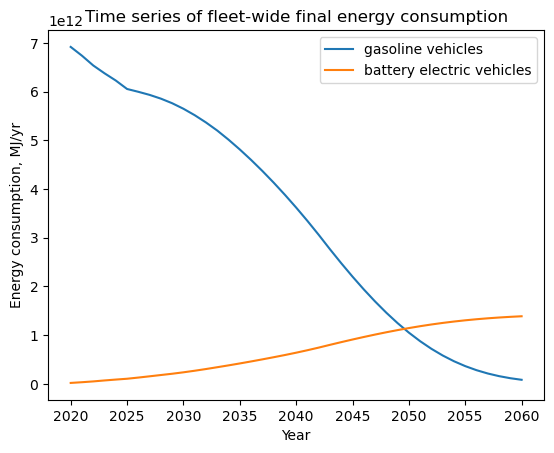

In [13]:
plt.plot(np.arange(2020,2061,1),E_tT[30::,:]) # plot with given x-axis values, generated with the np.arange command
plt.title('Time series of fleet-wide final energy consumption')
plt.ylabel('Energy consumption, MJ/yr')
plt.xlabel('Year')
plt.legend(['gasoline vehicles','battery electric vehicles']) # add a legend
plt.savefig('Energy_fleet_t.png', dpi = 300) # save figure with the modifications made above.

We see that the total energy consumption of the fleet keeps decreasing substantially, as vehicles become more efficient and the transition to electic vehicles unfolds, who need nees final energy per vkm.

### Task 3: Calculate the fleet-wide scope 1 and scope 2 GHG emissions for the given scenario of electric vehicle shares in new registration and grid decarbonisation!

For scope 2, the electricity emissions factor has to be treated separately. The given gasoline emissions factor contains scope 1+3 GHG, and we ignore the latter here and report it all unter scope 1 to keep things simple.

From the breakdown of the fleet into different drive technologies, we can compute the total energy consumption as follows, with the second dimension of the fuel intensity *MJ* as technology *T*:

$$ E(t) = \sum_{c,T} MJ(c,T) \cdot km(t) \cdot S(t,c,T) $$

$$ GHG(t) = \sum_{c,T} GHG(t,T) \cdot MJ(c,T) \cdot km(t) \cdot S(t,c) $$

$$ GHG(t,T) = \sum_{c} GHG(t,T) \cdot MJ(c,T) \cdot km(t) \cdot S(t,c) $$

In the latter equation, the drive technology index is kept, and we use this index to separate scope 1 (T=0, gasoline) from scope  2 (T=1, electricity).

In [14]:
df_GHG = pd.read_excel('Bath_dMFA_2026_Software_Data.xlsx', sheet_name='GHG_intensity', index_col=0)
df_GHG # print data
GHG_energy_t  = df_GHG.values
GHG_energy_t.shape

(71, 2)

In [15]:
GHG_tT = np.einsum('tcT,t,cT,tT->tT',DynFleetResults['S_Veh_tcT'],km_t,MJ_c,GHG_energy_t)/1e12 # take full array MJ_c with c and T dimensions
# Convert CO_2 unit from g to Mt.
GHG_tT.shape # has no extra dimension as we sum up over both drive technologies

(71, 2)

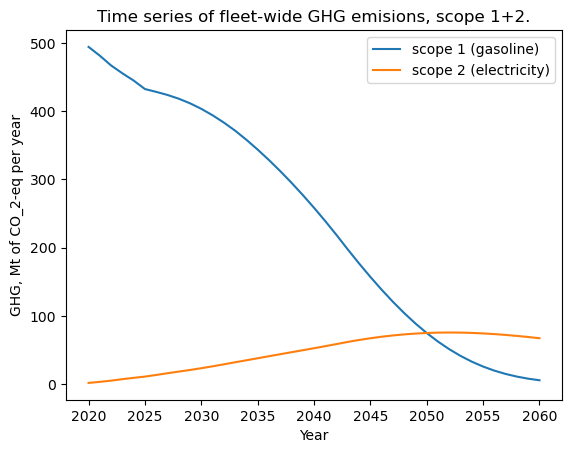

In [16]:
plt.plot(np.arange(2020,2061,1),GHG_tT[30::,:]) # plot the result
plt.title('Time series of fleet-wide GHG emisions, scope 1+2.')
plt.ylabel('GHG, Mt of CO_2-eq per year')
plt.xlabel('Year')
plt.legend(['scope 1 (gasoline)','scope 2 (electricity)'])
plt.savefig('GHG_fleet_tT.png', dpi = 300)

Let' use different type of plot this time:

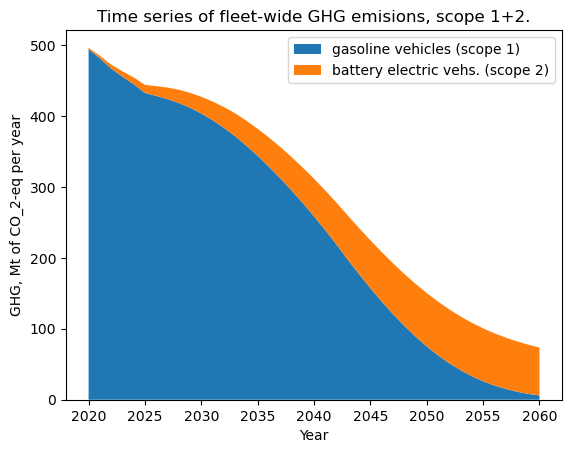

In [17]:
plt.stackplot(np.arange(2020,2061,1),GHG_tT[30::,0],GHG_tT[30::,1]) # plot the result
plt.title('Time series of fleet-wide GHG emisions, scope 1+2.')
plt.ylabel('GHG, Mt of CO_2-eq per year')
plt.xlabel('Year')
plt.legend(['gasoline vehicles (scope 1)','battery electric vehs. (scope 2)'])
plt.savefig('GHG_fleet_tT_stacked.png', dpi = 300)

From the figures, we can see that for the given scenario of future demand, electric vehicle phase-in and electricity decarbonisation, scope 1+2 GHG emissions are bound for a sharp decline down to less than a fifth of current values.

Policy-relevant claim: Under the given drive technology shift and electricity grid decarbonisation trajectory, total emissions can drop by more than 80%, despite further growth in vkm and pkm until 2060.

### Task 4: What are the fleet-wide material-related GHG (scope 3) and the raw material use (natural resource use) implications of the different recycling scenarios?

Calculate and plot the result!

We first read the impact data, which are given per material (primary or secondary), *ImpPrimMat(m,I)* and *ImpSecMat(m,I)*, and which come with an impact dimension *I*.

We first calculate the primary production *PrimMat* as the material that is supplied from primary recources:

$$ PrimMat(t,m) = I(t,m) - SecMat(t,m)$$

(This was done in the previous workbook already, here, we can load the result.)

We then calcualate the impacts, *Imp(I,t)*, by summing up the impacts from primary and secondary production:

$$ Imp(t,I) = \sum_{m} ImpPrimMat(m,I) \cdot PrimMat(t,m) + \sum_{m} ImpSecMat(m,I) \cdot SecMat(t,m) $$

The calculations above are repeated for both scenarios (add scenario dependency to the material flows):

$$ Imp(t,I,S) = \sum_{m} ImpPrimMat(m,I) \cdot PrimMat(t,m,S) + \sum_{m} ImpSecMat(m,I) \cdot SecMat(t,m,S) $$

In [18]:
# We first load the footprint data and then multiply them to the time series of material production:
ImpPrimMat = pd.read_excel('Bath_dMFA_2026_Software_Data.xlsx', sheet_name='Env_impacts_primary_materials', index_col=0).values
print(ImpPrimMat.shape)
ImpSecMat = pd.read_excel('Bath_dMFA_2026_Software_Data.xlsx', sheet_name='Env_impacts_secondary_materials', index_col=0).values
print(ImpSecMat.shape)

(10, 4)
(10, 4)


In [19]:
# Look at what's available in the pickled results:
with open('Bath_dMFA_2026_Software_4_Results.pkl', 'rb') as f:
    MatCycleResults = pickle.load(f) # deserialize using load()
MatCycleResults.keys()

dict_keys(['I_tm', 'S_tm', 'O_tm', 'FRec', 'FPrim'])

In [20]:
# Calculate the material supply chain (scope 3) impacts, over time, for different impact categories, all materials, and by scenario
Imp_tmIS = np.einsum('mI,tmS->tmIS',ImpPrimMat,MatCycleResults['FPrim']) + np.einsum('mI,tmS->tmIS',ImpSecMat,MatCycleResults['FRec'])

# The unit of the material flows is Mt/yr.
# The unit of the scope 3 GHG here is Mt CO2-eq/yr (since the GHG multiplier has the unit kg/kg).
# The unit of the material footprints (raw material equivalents) is Mt/yr (since the material footprint multipliers have the unit kg/kg).

We now evaluate this array for a number of impact categories.
First, the scope 3 emissions broken down into materials:

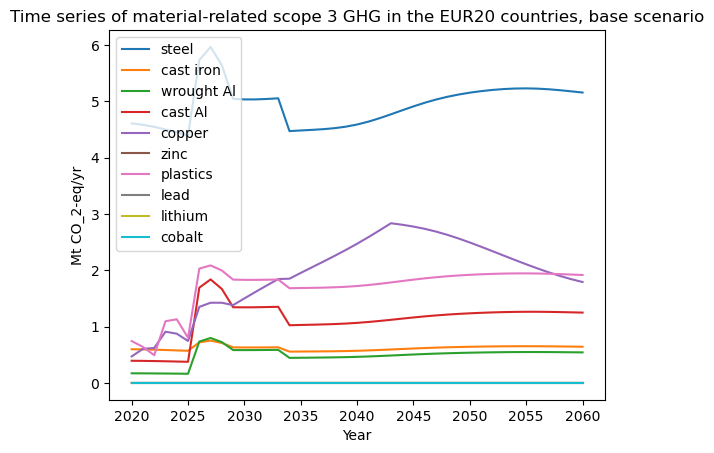

In [21]:
plt.plot(np.arange(2020,2061,1),Imp_tmIS[30::,:,0,0]) 
plt.title('Time series of material-related scope 3 GHG in the EUR20 countries, base scenario')
plt.ylabel('Mt CO_2-eq/yr')
plt.xlabel('Year')
plt.legend(['steel','cast iron','wrought Al','cast Al','copper','zinc','plastics','lead','lithium','cobalt'])

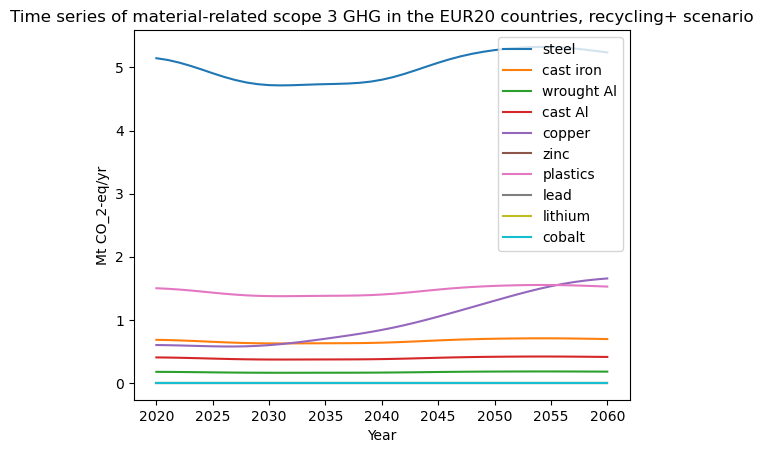

In [22]:
plt.plot(np.arange(2020,2061,1),Imp_tmIS[30::,:,0,1]) 
plt.title('Time series of material-related scope 3 GHG in the EUR20 countries, recycling+ scenario')
plt.ylabel('Mt CO_2-eq/yr')
plt.xlabel('Year')
plt.legend(['steel','cast iron','wrought Al','cast Al','copper','zinc','plastics','lead','lithium','cobalt'])

We see that the GHG in the improved recycling scenario are a bit lower than in the base case. Moreover, the curves are much smoother than in the base case, indicating that the smooth recycled material curves dominate supply and not the jumpy final demand.

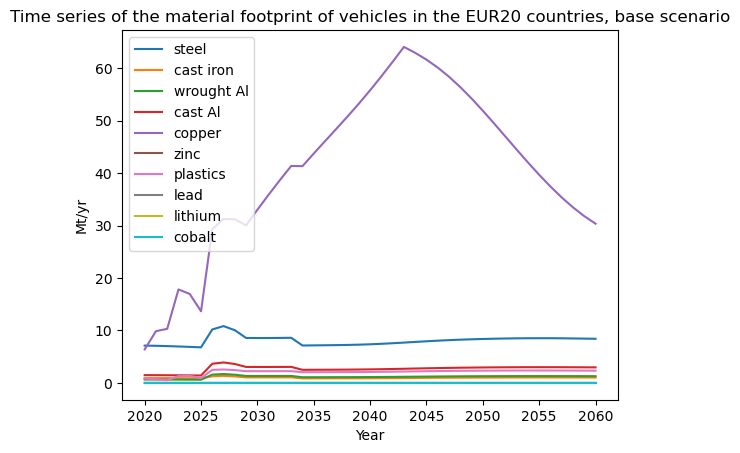

In [23]:
plt.plot(np.arange(2020,2061,1),Imp_tmIS[30::,:,1,0]) 
plt.title('Time series of the material footprint of vehicles in the EUR20 countries, base scenario')
plt.ylabel('Mt/yr')
plt.xlabel('Year')
plt.legend(['steel','cast iron','wrought Al','cast Al','copper','zinc','plastics','lead','lithium','cobalt'])

We see that the material footprint of the vehicle fleet is dominated by copper, translating into large land use, waste, and wastewater emissions from copper mining.
The reason for this dominance is twofold: First, the low ore grade of copper, leading to a very high material footprint per kg (ca. 170 kg/kg) and second, the increasing copper content of BEVs (4-5 times more copper per vehicle than in a gasoline car).

### Task 5: Plot the total system-wide GHG (scope 1+2+3) as stacked plot for the base scenario!

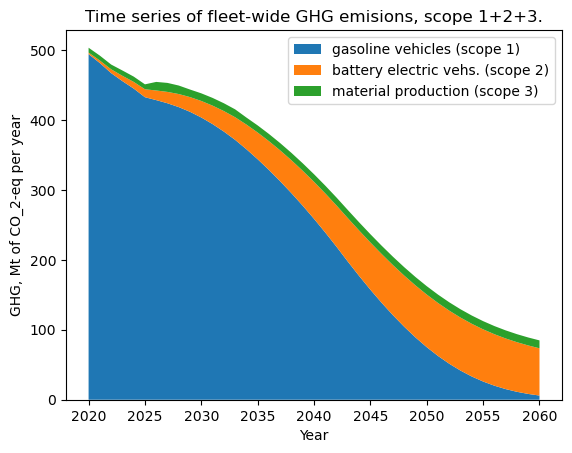

In [24]:
GHG_scope3_base = np.einsum('tm->t',Imp_tmIS[:,:,0,0]) # select base scenario and GHG impact, sum up over materials m
# Check units! All in Mt CO2-eq/yr.
plt.stackplot(np.arange(2020,2061,1),GHG_tT[30::,0],GHG_tT[30::,1],GHG_scope3_base[30::]) # plot the result
plt.title('Time series of fleet-wide GHG emisions, scope 1+2+3.')
plt.ylabel('GHG, Mt of CO_2-eq per year')
plt.xlabel('Year')
plt.legend(['gasoline vehicles (scope 1)','battery electric vehs. (scope 2)','material production (scope 3)'])
plt.savefig('GHG_fleet_tT_stacked123.png', dpi = 300)

We see that material production adds to the overall GHG balance of the fleet but scope 1+2 GHG dominate the picture.

In reality, the scope 3 GHG of the vehicle fleet are much larger, because vehicles mostly use primary materials for their manufacturing.
In a last step, we thus re-calculate the scope 3 GHG in a scenario without any recycling, assuming that the entire inflow, *I_tm* is sourced from primary production.

In [25]:
# Calculate the material supply chain (scope 3) impacts, over time, for different impact categories, and all materials.
Imp_tmI_NoRec = np.einsum('mI,tm->tmI',ImpPrimMat,MatCycleResults['I_tm'])

# The unit of the material flows is Mt/yr.
# The unit of the scope 3 GHG here is Mt CO2-eq/yr (since the GHG multiplier has the unit kg/kg).
# The unit of the material footprints (raw material equivalents) is Mt/yr (since the material footprint multipliers have the unit kg/kg).

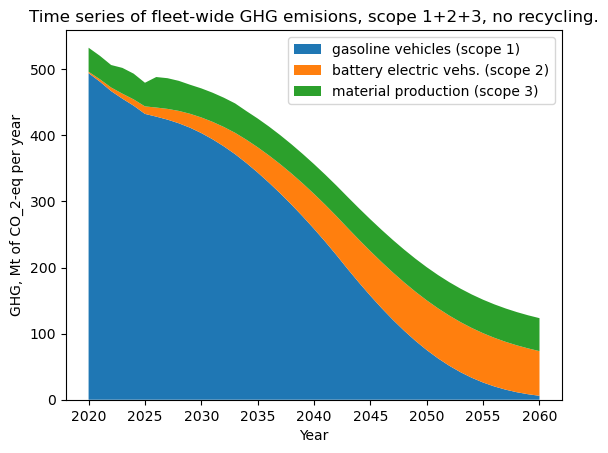

In [26]:
GHG_scope3_NoRec = np.einsum('tm->t',Imp_tmI_NoRec[:,:,0]) # select GHG impact, sum up over materials m
# Check units! All in Mt CO2-eq/yr.
plt.stackplot(np.arange(2020,2061,1),GHG_tT[30::,0],GHG_tT[30::,1],GHG_scope3_NoRec[30::]) # plot the result
plt.title('Time series of fleet-wide GHG emisions, scope 1+2+3, no recycling.')
plt.ylabel('GHG, Mt of CO_2-eq per year')
plt.xlabel('Year')
plt.legend(['gasoline vehicles (scope 1)','battery electric vehs. (scope 2)','material production (scope 3)'])
plt.savefig('GHG_fleet_tT_stacked123_NoRec.png', dpi = 300)

In this scenario, which is closer to the current reality, the scope 3 emissions are much more substantial than in a close-to-closed-loop scenario. 

Using materials more efficiently (light-weighting), better recycling, low-carbon material production are circular economy strategies that are crucial to brinding down raw material use and scope 3 GHG for a low-carbon transport future.

This evaluation concludes this exercise.
A number of additional evaluations and refinements could follow.
For example, testing for different BEV adoption rates, different vehicle sizes, or analysing the trade-off between scope 1/2 and 3 GHG of a longer vehicle lifetime (less material use vs. slower adoption of BEVs in the fleet).